In [1]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import keras_tuner as kt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np
import random

import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt
import seaborn as sns


# import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler,StandardScaler,OneHotEncoder,OrdinalEncoder
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau

SEED_VALUE=123
random.seed(SEED_VALUE)
np.random.seed(SEED_VALUE)

In [3]:
import pandas as pd
df = pd.read_parquet("1B.parquet")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Sales_ID           2000 non-null   int64  
 1   name               2000 non-null   object 
 2   year               2000 non-null   int64  
 3   selling_price      1998 non-null   float64
 4   km_driven          2000 non-null   int64  
 5   Region             2000 non-null   object 
 6   State or Province  2000 non-null   object 
 7   City               2000 non-null   object 
 8   fuel               2000 non-null   object 
 9   seller_type        2000 non-null   object 
 10  transmission       2000 non-null   object 
 11  owner              2000 non-null   object 
 12  mileage            2000 non-null   object 
 13  engine             2000 non-null   int64  
 14  max_power          2000 non-null   float64
 15  torque             2000 non-null   object 
 16  seats              2000 

In [4]:
df.head()

,Sales_ID,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,sold
0,1933,Maruti,2013,4500.00,41800,South,Florida,Orlando,Petrol,Individual,Manual,First_Owner,18.6,1197,85.8,114Nm@ 4000rpm,5,Y
1,4901,Ford,2004,4000.00,93415,East,Massachusetts,Abington,Diesel,Dealer,Manual,First_Owner,13.1,2499,141.0,330Nm@ 1800rpm,7,N
2,2802,Honda,2017,8199.99,12000,South,Arkansas,Benton,Petrol,Individual,Manual,First_Owner,17.5,1199,88.7,110Nm@ 4800rpm,5,N
3,7949,Maruti,2016,6750.00,108000,East,New York,East Massapequa,Diesel,Dealer,Manual,First_Owner,23.65,1248,88.5,200Nm@ 1750rpm,5,N
4,966,Maruti,2019,6750.00,5000,Central,Illinois,Chicago,Petrol,Individual,Automatic,First_Owner,21.4,1197,83.1,115Nm@ 4000rpm,5,Y


In [ ]:
df.drop(columns=['Sales_ID'], inplace=True)

In [6]:
categorical_columns=df.select_dtypes(include=['object', 'category']).columns
for col in categorical_columns:
  print(f"{col}:{df[col].unique()}")

name:['Maruti' 'Ford' 'Honda' 'Chevrolet' 'Renault' 'Hyundai' 'Volkswagen'
 'Mahindra' 'Datsun' 'Skoda' 'Tata' 'Toyota' 'Mercedes' 'Volvo' 'BMW'
 'Jeep' 'Audi' 'Jaguar' 'Mitsubishi' 'Fiat' 'Land' 'Nissan' 'Force'
 'Lexus' 'Isuzu' 'Daewoo' 'MG']
Region:['South' 'East' 'Central' 'West' 'N/A']
State or Province:['Florida' 'Massachusetts' 'Arkansas' 'New York' 'Illinois' 'Washington'
 'Alabama' 'Nevada' 'Minnesota' 'California' 'Colorado' 'Oregon'
 'Michigan' 'Ohio' 'Oklahoma' 'Indiana' 'Iowa' 'Texas' 'Georgia' 'Maine'
 'Maryland' 'New Jersey' 'Arizona' 'Kansas' 'Pennsylvania' 'Montana'
 'Virginia' 'Tennessee' 'New Hampshire' 'Mississippi' 'North Carolina'
 'West Virginia' 'Nebraska' 'Utah' 'District of Columbia' 'New Mexico'
 'Rhode Island' 'South Dakota' 'Kentucky' 'Wisconsin' 'South Carolina'
 'Missouri' 'Vermont' 'Connecticut' 'Louisiana' 'Delaware' 'Idaho'
 'North Dakota' 'Wyoming']
City:['Orlando' 'Abington' 'Benton' 'East Massapequa' 'Chicago' 'Redmond'
 'Madison' 'Reno' 'Apple Vall

In [7]:
df['mileage']=pd.to_numeric(df['mileage'], errors='coerce')
non_numeric = df[pd.to_numeric(df['mileage'], errors='coerce').isna()]['mileage']
print(non_numeric)

df['mileage'] = df['mileage'].fillna(df['mileage'].median())

647    NaN
846    NaN
1033   NaN
1067   NaN
Name: mileage, dtype: float64


In [8]:
na_count = (df['Region'] == 'N/A').sum()
total = len(df)

print(f"Jumlah N/A: {na_count}")
print(f"Persentase: {na_count / total * 100:.2f}%")

Jumlah N/A: 2
Persentase: 0.10%


In [9]:
mode_value = df['Region'].mode()[0]
df['Region'] = df['Region'].replace('N/A', mode_value).fillna(mode_value)

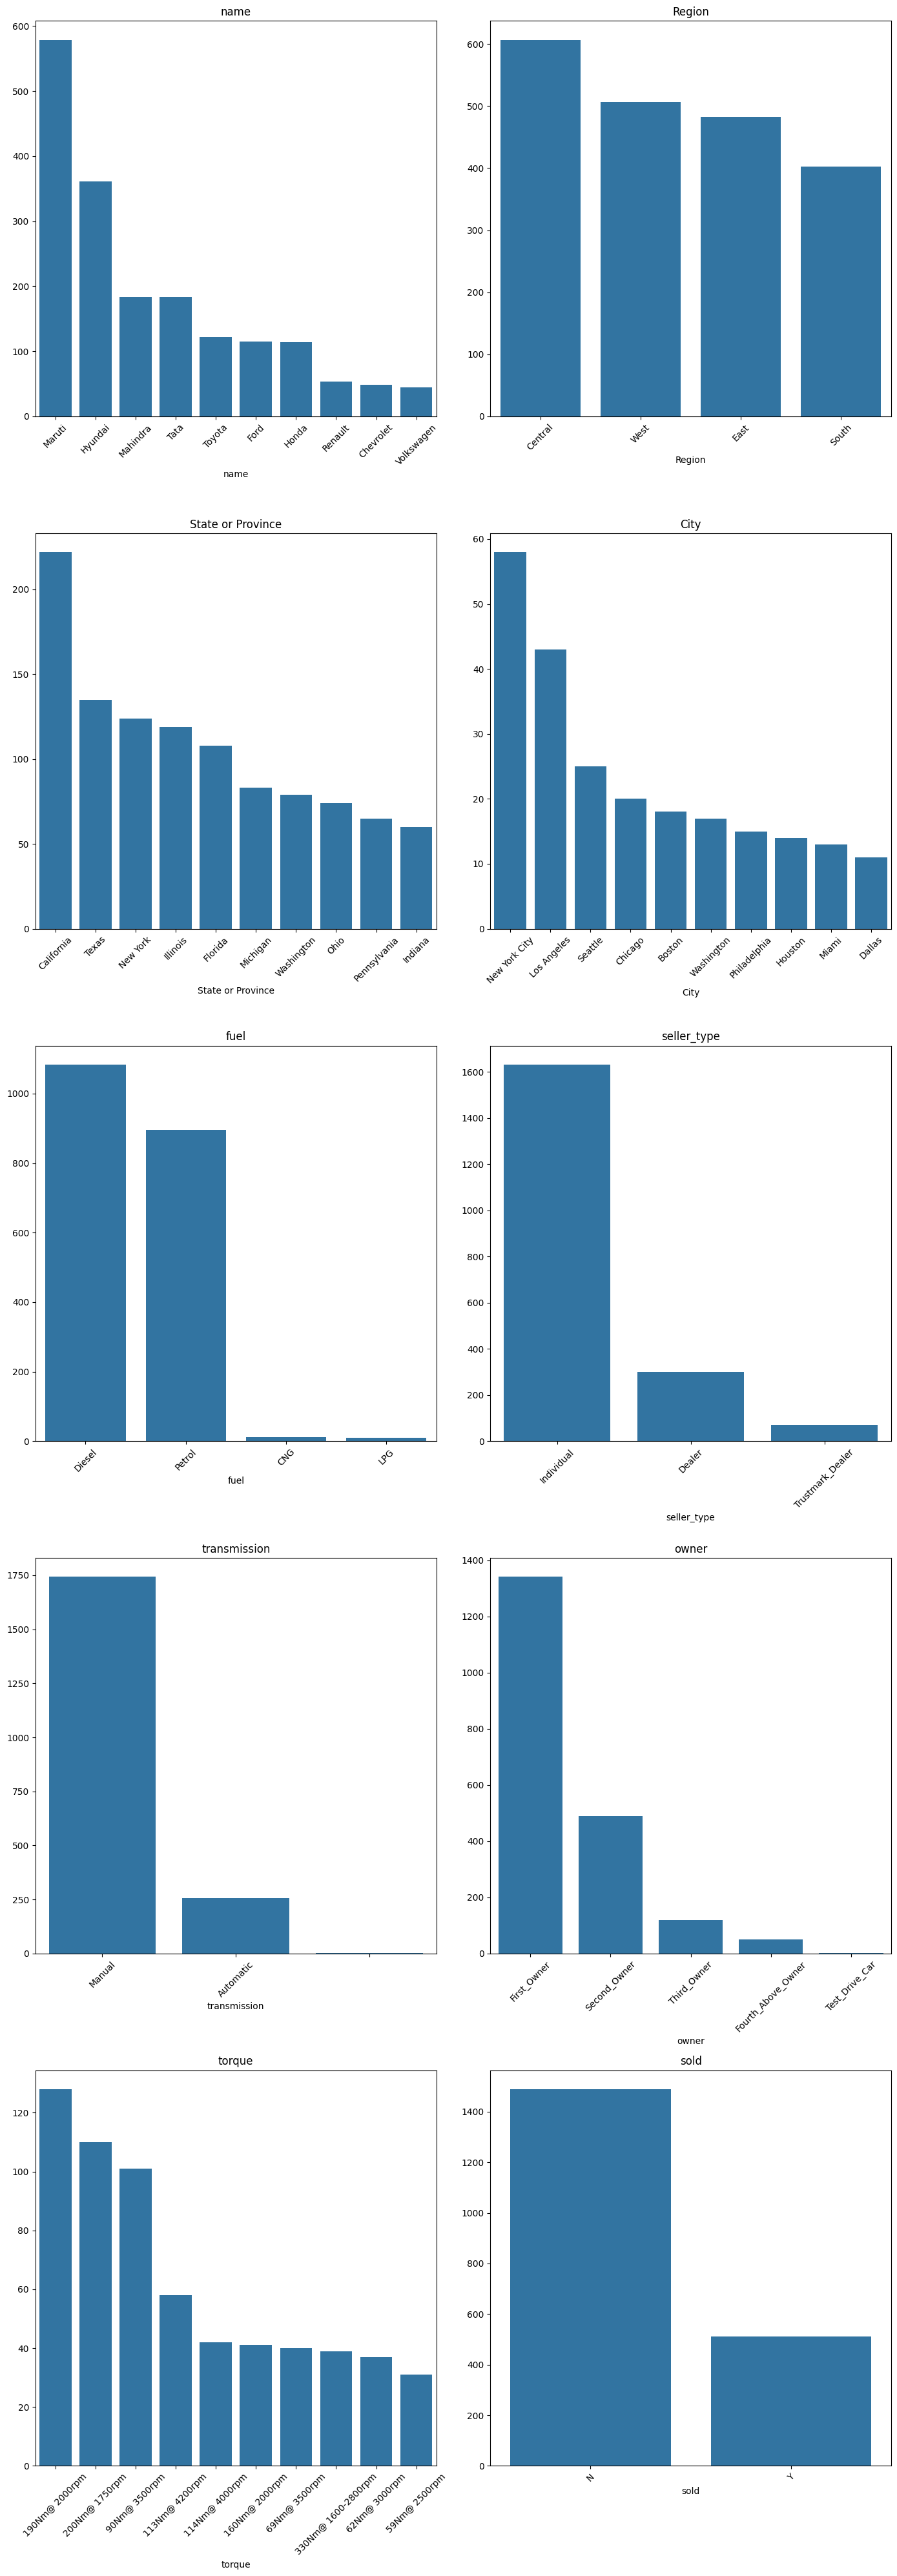

In [ ]:
cat_cols = df.select_dtypes(include='object').columns

fig, axes = plt.subplots(len(cat_cols)//2 + len(cat_cols)%2, 2, figsize=(14, 4*len(cat_cols)))
axes = axes.ravel()

for ax, col in zip(axes, cat_cols):
    top = df[col].value_counts().head(10)
    sns.barplot(x=top.index, y=top.values, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

for ax in axes[len(cat_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

Insight:

-Dari Top 5 mobil yang dijual, 3 berasal dari India, Toyota dari Jepang dan Hyundai dari Korea Selatan.
-Mobil menggunakan mayoritas menggunakan transmission manual.
-Mobil yang akan dijual mayoritas dari pemilik pertama dan tidak melalui perantara
-Mobil mayoritas belum berhasil terjual.
-Mayoritas mobil berasal dari region Central.

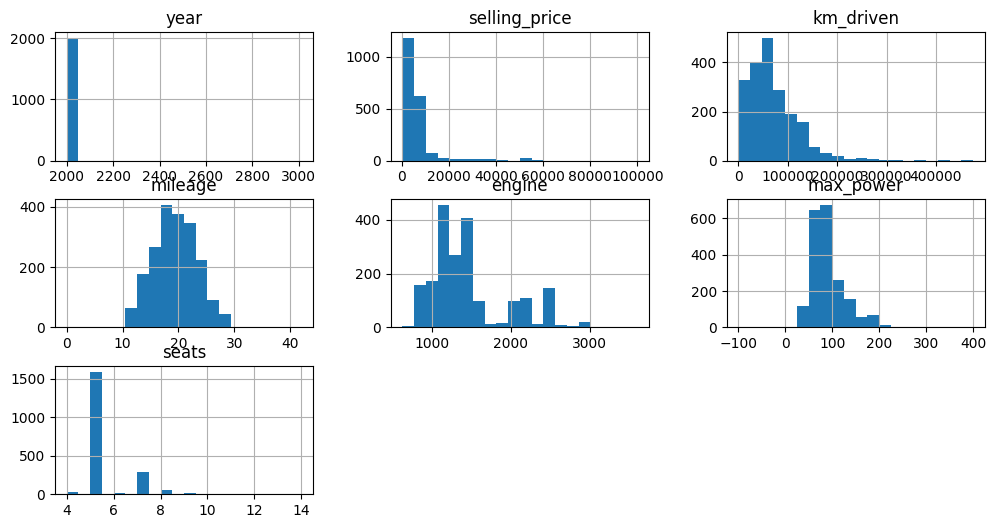

In [ ]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
df[numerical_columns].hist(bins=20, figsize=(12, 6))
plt.show()

Insight:
-Mobil yang dijual merupakan mobil produksi 2000-2020 awal. 
-Selling pricenya mobil bekas ini rata-rata dibawah USD 20000
-Panjang jalan yang dilalui oleh kendaraan sebagian besar mencapai 100000 km
-Engine untuk mobil sebagian besar di angka 750 - 1500.
-Max power untuk mobil berkisar diangka 20-210 namun sebagian besar berada di 50-100.
-Mayoritas mobil memiliki 5 seats

In [12]:
median_value = df['selling_price'].median()
df['selling_price'] = df['selling_price'].fillna(median_value)

In [ ]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include=['object']).columns

In [ ]:
x = df.drop(columns='selling_price')
y = df['selling_price']
x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=0.2, random_state=SEED_VALUE)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.125, random_state=SEED_VALUE)

print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)
print(x_test.shape, y_test.shape)

(1400, 16) (1400,)
(200, 16) (200,)
(400, 16) (400,)


In [15]:
ohe_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
new_cat_cols = ohe_encoder.fit_transform(x_train[categorical_columns])
encoded_data = pd.DataFrame(new_cat_cols,columns=ohe_encoder.get_feature_names_out(categorical_columns))

x_train = x_train.reset_index(drop=True)
x_train = pd.concat([x_train.drop(categorical_columns, axis=1, errors='ignore'), encoded_data], axis=1 )

new_cat_cols = ohe_encoder.transform(x_val[categorical_columns])
encoded_data = pd.DataFrame(new_cat_cols, columns=ohe_encoder.get_feature_names_out(categorical_columns))
x_val = x_val.reset_index(drop=True)
x_val = pd.concat( [x_val.drop(categorical_columns, axis=1, errors='ignore'), encoded_data], axis=1 )

new_cat_cols = ohe_encoder.transform(x_test[categorical_columns])
encoded_data = pd.DataFrame( new_cat_cols, columns=ohe_encoder.get_feature_names_out(categorical_columns) )
x_test = x_test.reset_index(drop=True)
x_test = pd.concat( [x_test.drop(categorical_columns, axis=1, errors='ignore'), encoded_data], axis=1)

Kode ini mengubah numerik menjadi kategorikal menggunakan OneHotEncoder. Prosesnya dimulai dengan melakukan fit dan transform pada x_train, di mana encoder mempelajari seluruh kategori yang ada lalu mengubahnya menjadi representasi biner (0 dan 1). Hasil encoding kemudian diubah menjadi DataFrame dengan nama kolom baru yang sesuai, lalu digabungkan kembali dengan data leakage.

In [16]:
x_train.head()

,year,km_driven,mileage,engine,max_power,seats,name_Audi,name_BMW,name_Chevrolet,name_Datsun,...,torque_91Nm@ 4250rpm,torque_94.14Nm@ 3500rpm,torque_95Nm@ 3000-4300rpm,torque_96.1Nm@ 3000rpm,torque_96Nm@ 2500rpm,torque_99.04Nm@ 4500rpm,torque_99.8Nm@ 2700rpm,torque_99Nm@ 4500rpm,sold_N,sold_Y
0,2014,84784,24.00,1120,70.00,5,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2012,77000,22.32,1582,126.32,5,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,2019,40000,23.80,1498,78.90,5,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,2009,52000,18.90,1061,67.00,5,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2016,23400,23.95,998,67.10,5,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [17]:
scaler = StandardScaler()
numerical_columns = numerical_columns.drop('selling_price', errors='ignore')
x_train[numerical_columns] = scaler.fit_transform(x_train[numerical_columns])
x_val[numerical_columns] = scaler.transform(x_val[numerical_columns])
x_test[numerical_columns] = scaler.transform(x_test[numerical_columns])

Disini, saya melakukan scaling untuk data numerik dengan menghapus selling_price dari kolom numerik agar tidak ikut diproses, karena target tidak boleh diubah. Kemudian pada x_train dilakukan fit dan transform, di mana scaler menghitung rata-rata dan standar deviasi dari setiap fitur, lalu mengubah nilainya sehingga memiliki distribusi dengan mean = 0 dan std = 1. Setelah itu, untuk x_val dan x_test, hanya dilakukan transform menggunakan parameter yang sudah dipelajari dari data training agar konsistensi tetap terjaga dan tidak terjadi data leakage.

In [18]:
y_train = y_train.values
y_val = y_val.values
y_test = y_test.values

In [19]:
train_ds = tf.data.Dataset.from_tensor_slices((x_train,y_train)).batch(32).shuffle(10)
test_ds = tf.data.Dataset.from_tensor_slices((x_test,y_test)).batch(32)
val_ds = tf.data.Dataset.from_tensor_slices((x_val,y_val)).batch(32)

Dengan menggunakan tensorflow,proses training model menjadi lebih cepat dan terstruktur. Pada train_ds, data diambil menggunakan from_tensor_slices lalu model memproses 32 data sekaligus dalam satu iterasi dan dishuffle supaya urutan data diacak dan model tidak belajar dari pola urutan tertentu.Val_ds dan test_ds hanya dibatch tanpa shuffle karena data validasi dan testing tidak perlu diacak hanya untuk evaluasi performa model secara konsisten. 


In [20]:
train_ds

<ShuffleDataset element_spec=(TensorSpec(shape=(None, 1114), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.float64, name=None))>

In [21]:
print(x_train.shape)

(1400, 1114)


In [ ]:
input_dimension = x_train.shape[1]

model = Sequential([
    Dense(2228, activation='relu', input_shape=(input_dimension,)),
    Dense(2228, activation='relu'),
    Dense(1)  
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 2228)              2484220   
                                                                 
 dense_1 (Dense)             (None, 2228)              4966212   
                                                                 
 dense_2 (Dense)             (None, 1)                 2229      
                                                                 
Total params: 7,452,661
Trainable params: 7,452,661
Non-trainable params: 0
_________________________________________________________________


In [23]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
              ,loss=tf.keras.losses.MeanSquaredError()
              ,metrics=[tf.keras.metrics.MeanAbsoluteError(),tf.keras.metrics.RootMeanSquaredError()])

In [24]:
history_seq = model.fit(train_ds,validation_data=val_ds,epochs = 50)

Epoch 1/50
44/44 [==============================] - 1s 8ms/step - loss: 91803792.0000 - mean_absolute_error: 5553.7202 - root_mean_squared_error: 9581.4297 - val_loss: 98554088.0000 - val_mean_absolute_error: 3998.6028 - val_root_mean_squared_error: 9927.4414
Epoch 2/50
44/44 [==============================] - 0s 6ms/step - loss: 43820556.0000 - mean_absolute_error: 3120.3696 - root_mean_squared_error: 6619.7095 - val_loss: 55081912.0000 - val_mean_absolute_error: 3292.0557 - val_root_mean_squared_error: 7421.7188
Epoch 3/50
44/44 [==============================] - 0s 5ms/step - loss: 24071134.0000 - mean_absolute_error: 2396.6865 - root_mean_squared_error: 4906.2344 - val_loss: 31757840.0000 - val_mean_absolute_error: 2760.6514 - val_root_mean_squared_error: 5635.4092
Epoch 4/50
44/44 [==============================] - 0s 5ms/step - loss: 16502998.0000 - mean_absolute_error: 2120.3091 - root_mean_squared_error: 4062.3882 - val_loss: 23053742.0000 - val_mean_absolute_error: 2430.2007 -

In [25]:
model.evaluate(test_ds)

13/13 [==============================] - 0s 2ms/step - loss: 8214535.5000 - mean_absolute_error: 1649.8286 - root_mean_squared_error: 2866.1011


[8214535.5, 1649.82861328125, 2866.10107421875]

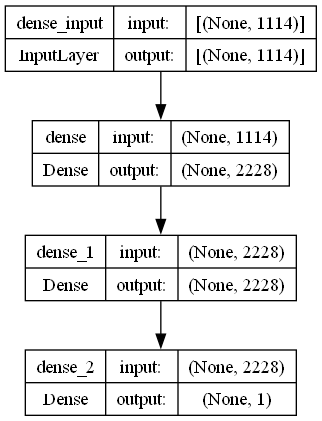

In [26]:
plot_model(model,show_shapes=True)

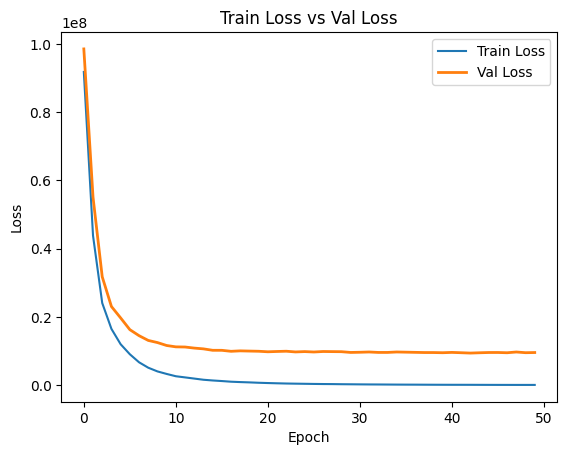

In [27]:
train_loss = history_seq.history['loss']
val_loss = history_seq.history['val_loss']
plt.plot(train_loss,label="Train Loss")
plt.plot(val_loss,label='Val Loss', linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train Loss vs Val Loss")
plt.legend()
plt.show()

Di sekitar 10 epoch awal, train loss dan validation loss turun drastid dan ini berarti bahwa learning rate model cukup baik. Garis train dan validation dekat sepanjang training yang berarti model tidak overfitting. Di antara epoch ke 20-30, model sudah mendekati konvergen atau tidak banyak improvement lagi. 

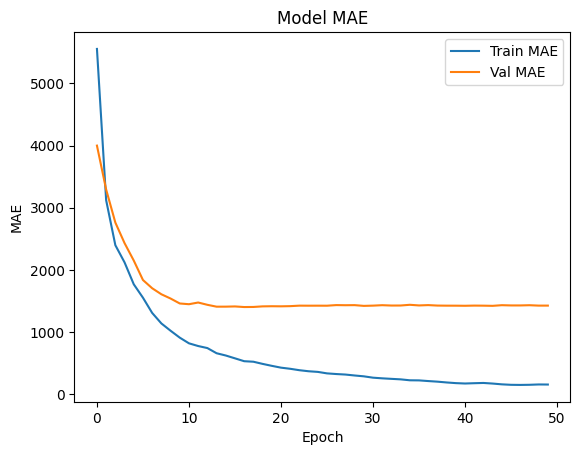

In [28]:
plt.plot(history_seq.history['mean_absolute_error'], label='Train MAE')
plt.plot(history_seq.history['val_mean_absolute_error'], label='Val MAE')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Model MAE")
plt.show()

Train MAE turun drastis hal ini berarti model semakin fit terhadap data training. Namun, validation MAE hanya turun di awal dan stagnan di angka 1000-2000 dari epoch ke 10 dan seterusnya. Hal ini berarti model berhenti belajar dan sudah mulai overfit. Gap antar kedua ini pun juga besar yang menandakan model perform baik saat data training namun buruk saat di data baru. 

13/13 [==============================] - 0s 1ms/step


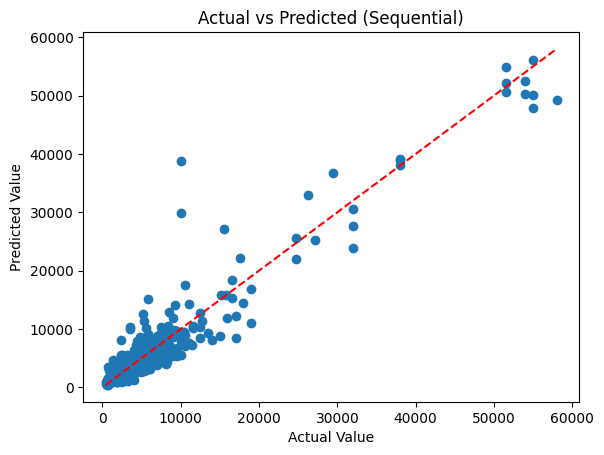

In [29]:
y_pred_seq = model.predict(x_test)

plt.scatter(y_test, y_pred_seq)

# garis ideal (y = x)
min_val = min(y_test.min(), y_pred_seq.min())
max_val = max(y_test.max(), y_pred_seq.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")
plt.title("Actual vs Predicted (Sequential)")
plt.show()

Plot ini memperlihatkan bahwa untuk nilai kecil (0-10000), titik-titik bisa terbilang cukup rapat, artinya model cukup akurat untuk nilai kecil. Namun unttuk actual value > 20000, banyak titik yang jauh dari garis, ada yang terlalu tinggi dan terlalu rendah. Artinya model belum bisa menangani nilai besar.

In [30]:
mae = mean_absolute_error(y_test, y_pred_seq)
mse = mean_squared_error(y_test, y_pred_seq)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_seq)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 1649.8286385467532
MSE : 8214535.708365676
RMSE: 2866.1011336597453
R2  : 0.8989603909835806


Dari MAE, rata-rata error prediksi mencapai 1649. Target mencapai kurang lebih 60000, sehingga error ini relatif kecil. Ada outlier yang cukup jauh dari MAE sekitar 2866 yang dibuktikan dengan plot actual vs predicted. Dari R2 bisa dilihat bahwa model bisa menjelaskan sekitar 89.9% dari variasi data.

In [ ]:
model1 = Sequential([
    Dense(256, activation='relu', kernel_regularizer=l2(0.001), input_shape=(input_dimension,)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    
    Dense(1)
])

model1.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
              ,loss=tf.keras.losses.MeanSquaredError()
              ,metrics=[tf.keras.metrics.MeanAbsoluteError(),tf.keras.metrics.RootMeanSquaredError()])


early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

history1 = model1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)


Epoch 1/50
44/44 [==============================] - 1s 10ms/step - loss: 102013504.0000 - mean_absolute_error: 6334.3291 - root_mean_squared_error: 10100.1729 - val_loss: 141748272.0000 - val_mean_absolute_error: 6856.8438 - val_root_mean_squared_error: 11905.8086 - lr: 0.0010
Epoch 2/50
44/44 [==============================] - 0s 7ms/step - loss: 101580136.0000 - mean_absolute_error: 6321.1787 - root_mean_squared_error: 10078.6973 - val_loss: 141501664.0000 - val_mean_absolute_error: 6852.1230 - val_root_mean_squared_error: 11895.4473 - lr: 0.0010
Epoch 3/50
44/44 [==============================] - 0s 7ms/step - loss: 100351600.0000 - mean_absolute_error: 6283.0391 - root_mean_squared_error: 10017.5645 - val_loss: 140787568.0000 - val_mean_absolute_error: 6838.6401 - val_root_mean_squared_error: 11865.3936 - lr: 0.0010
Epoch 4/50
44/44 [==============================] - 0s 8ms/step - loss: 97967112.0000 - mean_absolute_error: 6217.3394 - root_mean_squared_error: 9897.8340 - val_loss: 

Dari mengurangi neuron menjadi 256, saya berharap bahwa kompleksitas model dapat menurun. Selain itu dropout ditambahkan untuk mencegah model menghafal data training dan mengurangi overfitting. L2 Regularization ditambahkan untuk membatasi nilai bobot supaya tidak terlalu besar. Disini saya juga menambahkan batch normalization untuk membuat training lebih stabil. Terdapat juga optimizer Adam dan learning rate 0.001 untuk membuat nilai standar menjadi lebih stabil. Early stopping digunakan untuk menghemat waktu training dan menghentikan training saat validation tidak membaik. LrScheduler digunakan untuk menurunkan learning rate secara otomatis ketika model sudah tidak membaik supaya model memikirkan cara untuk menjadi lebih optimal. 

In [32]:
model1.evaluate(test_ds)

13/13 [==============================] - 0s 3ms/step - loss: 8263312.5000 - mean_absolute_error: 1803.8258 - root_mean_squared_error: 2874.5977


[8263312.5, 1803.8258056640625, 2874.59765625]

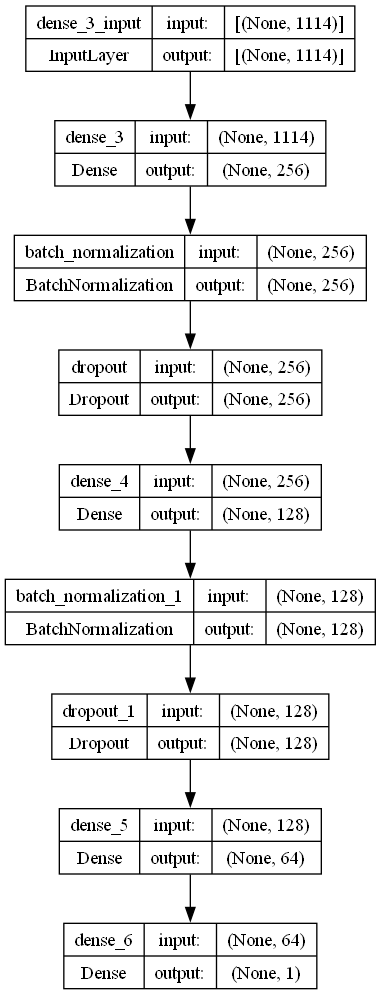

In [33]:
plot_model(model1,show_shapes=True)

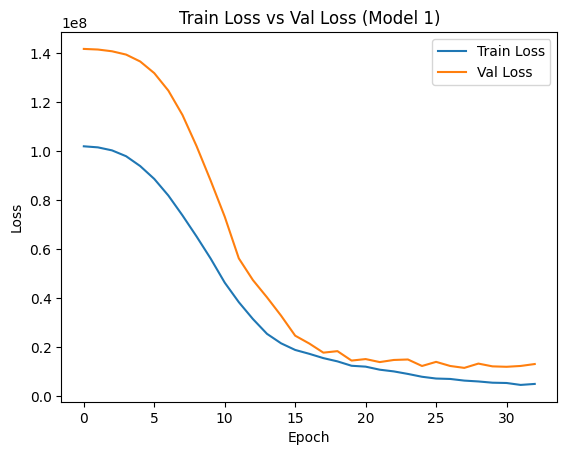

In [34]:
train_loss1= history1.history['loss']
val_loss1 = history1.history['val_loss']
plt.plot(train_loss1,label="Train Loss")
plt.plot(val_loss1,label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train Loss vs Val Loss (Model 1)")
plt.legend()
plt.show()

Dari plot ini dapat diketahui bahwa train dan validation loss turun dari epoch 0-15 menjadi sekitar 0.2. Setelah epoch ke 15, train loss terus turun dan validation loss mulai melambat dengan pergerakan naik turun yang menyebabkan terdapat gap diantara keduanya. Hal ini menunjukkan overfitting yang ringan dan validation loss yang stagnan menandakan bahwa model telah mencapai kapaisatas maksimalnya. Dengan ini, early stopping diimplementasikan dengan baik dan berhenti di sekitar epoch ke 35.

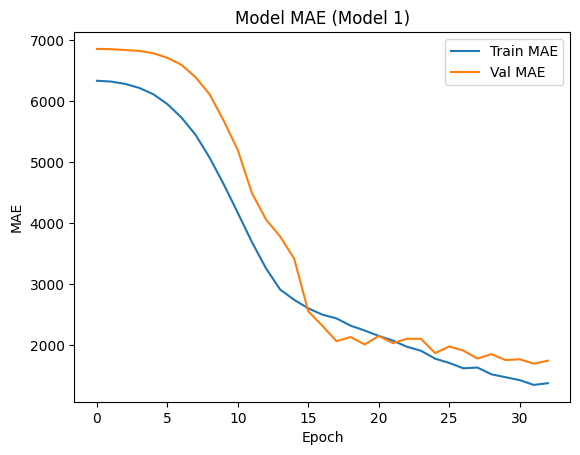

In [35]:
plt.plot(history1.history['mean_absolute_error'], label='Train MAE')
plt.plot(history1.history['val_mean_absolute_error'], label='Val MAE')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Model MAE (Model 1)")
plt.show()

Disini ditunjukkan bahwa MAE Train dan Val turun tajam di epoch awal, sekitar 0-15. Val MAE dari 7000 dan train MAE dari 6000 an menjadi kurang lebih 2000. Ini tanda learning menjadi efektif. Muncul gap yang tidak terlalu jauh mulai dari epoch ke 20 yang menunjukkan overfitiing ringan namun tidak separah model pertama. 

13/13 [==============================] - 0s 2ms/step


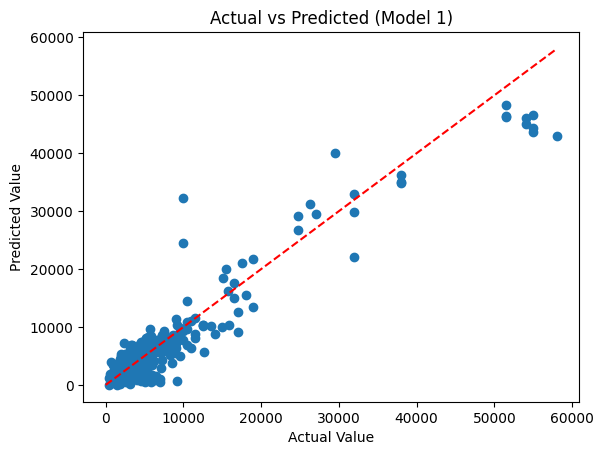

In [36]:
y_pred1 = model1.predict(x_test)

plt.scatter(y_test, y_pred1)

min_val = min(y_test.min(), y_pred1.min())
max_val = max(y_test.max(), y_pred1.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")
plt.title("Actual vs Predicted (Model 1)")
plt.show()

Dari sini, dapat terlihat bahwa sama dengan model pertama, performa cenderung baik untuk data dengan nilai kurang dari 10000. Untuk data di antara 200000 dan 40000, model belum sepenihnya stabil di sini sehingga variasi prediksi nya menyebar. Untuk nilai yang besar, model cenderung underpredict. 

In [37]:
mae_after = mean_absolute_error(y_test, y_pred1)
mse_after = mean_squared_error(y_test, y_pred1)
rmse_after = np.sqrt(mse_after)
r2_after = r2_score(y_test, y_pred1)

print("MAE :", mae_after)
print("MSE :", mse_after)
print("RMSE:", rmse_after)
print("R2  :", r2_after)

MAE : 1803.8259446121695
MSE : 8263312.273682734
RMSE: 2874.5977585886226
R2  : 0.898360434362322


Rata-rata error sekitar 1803, sedikit lebih besar dibandingkan model pertama. RMSE nya berada di 2874 yang berarti outlier masih ada dan tidak banyak berubah. R2 nya berada di 0.8983 yang berarti bahwa model bisa menjelaskan 89.83% dari variasi data. Maka ini berarti bahwa model 1 lebih baik secara keseluruhan dan kedua model ini tidak memiliki perbedaan yang signifikan. Model 2 tidak memberikan improvement. 

Link Youtube: https://youtu.be/ptO2VBIaijg